In [12]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from reaction_targeter import ReactionTargeter


col = pd.read_csv("lichens_20251030.csv")

mweights = []
for k in col["smiles"]:
    mol = Chem.MolFromSmiles(k)
    molWt = Descriptors.MolWt(mol)
    mweights.append(molWt)


rt = ReactionTargeter.from_commercial_index_file("cidx.pkl")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from typing import Any
import time

hits = []
times = []
for k in col["smiles"]:
    time_start = time.time()
    h = rt.run_1_ablation(k)
    time_taken = time.time() - time_start
    hits.append(h)
    times.append(time_taken)
all_df = pd.concat(hits)
all_df.to_csv("lichens_results.csv", index=False)

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial
import time

def _worker(k):
    time_start = time.time()
    hits = rt.run_1_ablation(k)
    time_taken = time.time() - time_start
    return hits

with ProcessPoolExecutor() as ex:
    results = list(ex.map(partial(_worker), col))
all_df = pd.concat(results)
all_df.to_csv("lichens_results.csv", index=False)

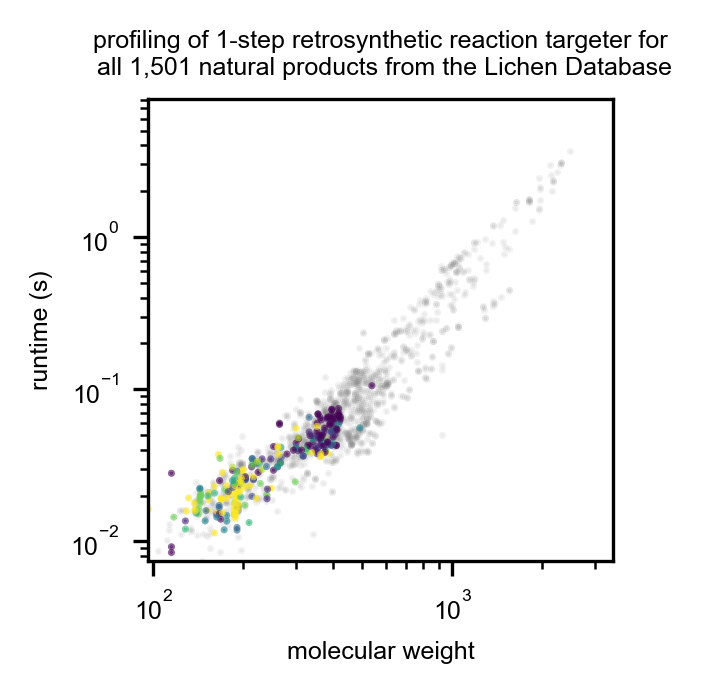

In [19]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "arial",
    'font.size': 6,
})

# results = pd.read_csv("results.csv")

fig, ax = plt.subplots(dpi=300, figsize=(2, 2))

# set all font sizes to 6
ax.tick_params(axis='both', which='major', labelsize=6)
ax.tick_params(axis='both', which='minor', labelsize=6)


x = []
y = []
c = []

xh = []
yh = []
ch = []
# for i,k in results.iterrows():
max_hits = 0
for idx, (k, ttime) in enumerate(zip(hits, times)):
    # print(k["molWt"], k["num_hits"], k["time_taken"])
    if len(k) > 0:
        xh.append(mweights[idx])
        ch.append(len(k))
        yh.append(ttime)
        if len(k) > max_hits:
            max_hits = len(k)
    else:
        x.append(mweights[idx])
        c.append(0)
        y.append(ttime)
# print(max_hits)
# import numpy as np
# print(np.mean(ch))
ax.set_yscale('log')
ax.set_xscale('log')
# ax.set_xlim(0, 2000)
# ax.set_ylim(-0.1, 2)
ax.scatter(x, y, c='grey', s=0.5, alpha=0.1, zorder=1)
ax.scatter(xh, yh, c=ch, s=0.5, alpha=0.6, zorder=2, vmax=10)
ax.set_xlabel("molecular weight", fontsize=6, fontfamily='arial')
ax.set_ylabel("runtime (s)", fontsize=6, fontfamily='arial')
ax.set_title("profiling of 1-step retrosynthetic reaction targeter for\n all 1,501 natural products from the Lichen Database", fontsize=6, fontfamily='arial')

plt.subplots_adjust(hspace=0, wspace=0)
plt.margins(0,0)

plt.savefig("profiling.png", dpi=300, bbox_inches="tight", pad_inches=0)
